In [3]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
a = ALNModel()

gradient_r = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 2 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-3):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu_up(a, a.params.sigmarange[sigma], a.params.Irange[mu], a.params.precalc_r)
        res2 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], a.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res2
        
def getindex(lower, upper, length, x_):
    return int( (x_ - lower) * (length-1) / (upper - lower) )

def get_value(lower, upper, length, index_):
    return lower + index_ * (upper - lower) / (length-1)

-1.0 7.0


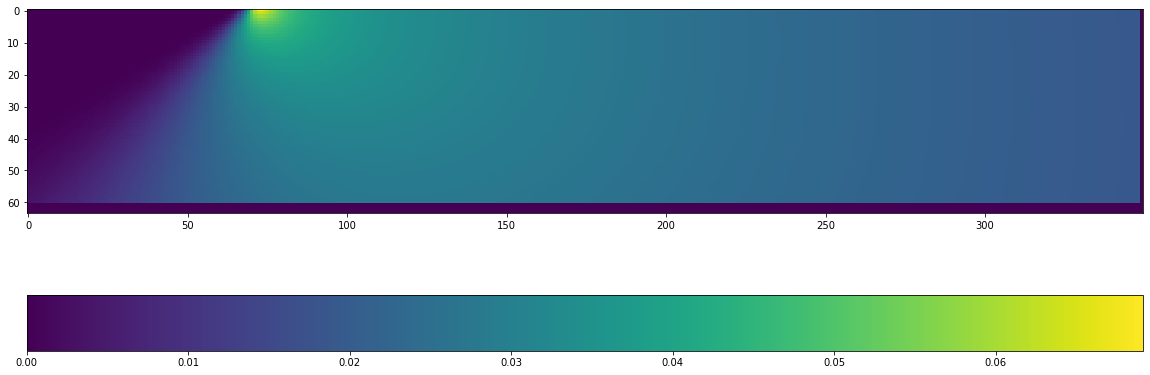

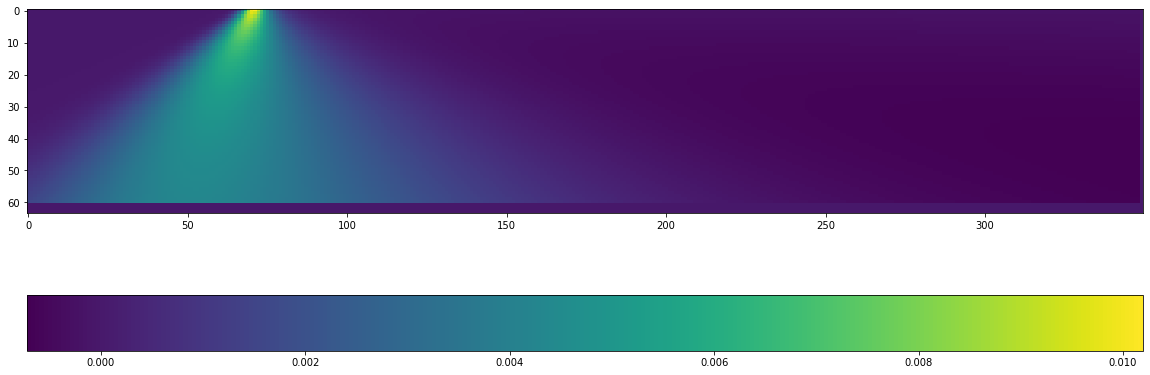

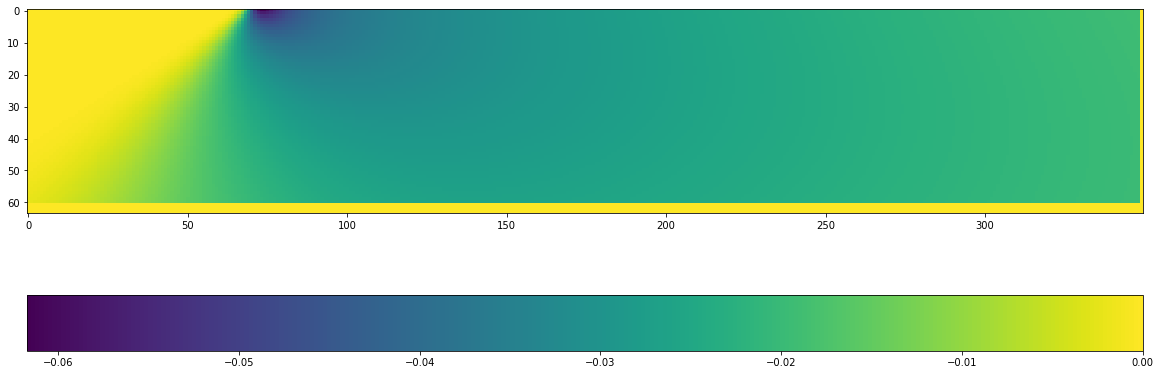

In [10]:
print(a.params.Irange[0], a.params.Irange[-1])

plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar(orientation="horizontal")
#plt.show()

plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,1].T)
plt.colorbar(orientation="horizontal")
#plt.show()

plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,1].T - gradient_r[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()